<a href="https://colab.research.google.com/github/Atharv-1905/Deep-Learning/blob/main/VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install the Kaggle library
!pip install -q kaggle

# 2. Upload the kaggle.json file you just downloaded
from google.colab import files
files.upload()

# 3. Create a kaggle directory and move the file there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# 4. Set permissions so the API can read the file
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
# Example: Replace this with your copied API command
!kaggle datasets download -d akash2sharma/tiny-imagenet

# Unzip the downloaded file
import zipfile
import os

# Find the name of the zip file (usually the last part of the dataset name)
zip_file = "tiny-imagenet.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('./data') # Extracts into a 'data' folder

print("Dataset unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/akash2sharma/tiny-imagenet
License(s): unknown
100% 474M/474M [00:30<00:00, 16.5MB/s]

Dataset unzipped successfully!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 64

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Using 20% for validation
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    './data/tiny-imagenet-200/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 80000 images belonging to 200 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    './data/tiny-imagenet-200/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 20000 images belonging to 200 classes.


In [ ]:
def build_vgg16(input_shape=(64, 64, 3), num_classes=200):
    model = models.Sequential(name="VGG16_TinyImageNet")

    # Block 1
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))


    # Block 2
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))


    # Block 3
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))


    # Block 4
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))


    # Block 5
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))


    # Fully Connected Classifier
    model.add(layers.Flatten())
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))


    return model




In [ ]:
vgg_model = build_vgg16()
vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001), # Slower LR for deep models
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "VGG16_TinyImageNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │       819,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,708,104 (155.29 MB)

 Trainable params: 40,708,104 (155.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = vgg_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 260s 192ms/step - accuracy: 0.0044 - loss: 5.2987 - val_accuracy: 0.0050 - val_loss: 5.2983
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 235s 188ms/step - accuracy: 0.0047 - loss: 5.2985 - val_accuracy: 0.0050 - val_loss: 5.2983
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 237s 190ms/step - accuracy: 0.0042 - loss: 5.2985 - val_accuracy: 0.0050 - val_loss: 5.2983
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 186ms/step - accuracy: 0.0042 - loss: 5.2984 - val_accuracy: 0.0050 - val_loss: 5.2983
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 229s 183ms/step - accuracy: 0.0041 - loss: 5.2984 - val_accuracy: 0.0050 - val_loss: 5.2983
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 234s 187ms/step - accuracy: 0.0041 - loss: 5.2984 - val_accuracy: 0.0050 - val_loss: 5.2983
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 232s 185ms/step - accuracy: 0.0044 - loss: 5.2984 - val_accuracy: 0.0050 - val_loss: 5.2983
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 229s 183ms/step - ac

In [ ]:
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

Final Training Accuracy: 0.0044
Final Validation Accuracy: 0.0050
Final Training Loss: 5.2984
Final Validation Loss: 5.2983


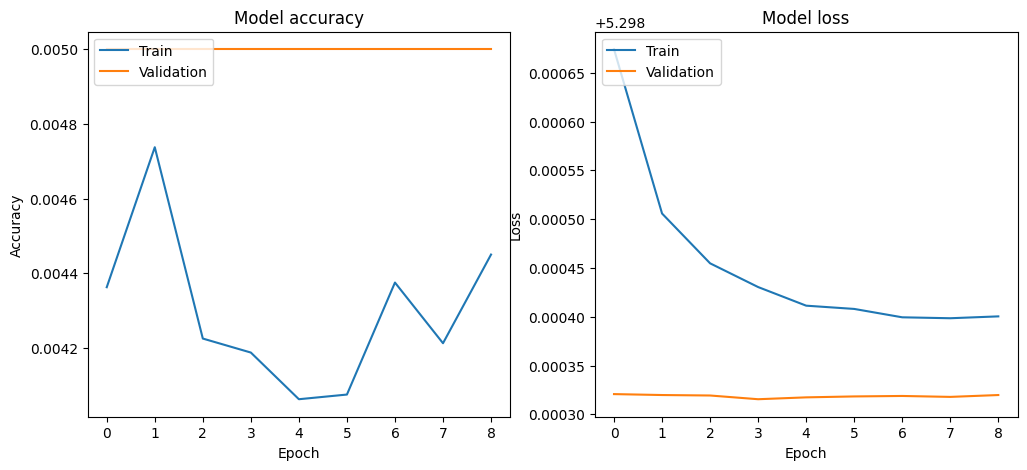

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Need to add batch normalization to avoid the vanishing gradient problem

## Next Steps After Adding Batch Normalization

Now that Batch Normalization layers have been added to the `build_vgg16` function, follow these steps to re-evaluate the model's performance:

1.  **Reinitialize Model**: Re-run the cell that calls `build_vgg16` to create a new model instance with the updated architecture. (Look for `vgg_model = build_vgg16()`).
2.  **Recompile Model**: Re-run the cell that compiles the model. This is crucial for the model to use the new architecture effectively. (This is usually the same cell as reinitializing).
3.  **Retrain Model**: Re-run the model training cell (`vgg_model.fit(...)`). The `EarlyStopping` callback is still in place to stop training if `val_loss` doesn't improve.
4.  **Evaluate New Model Performance**: After retraining, run the cells to print the final training and validation accuracy and loss, and plot the accuracy and loss curves again. This will help us compare the performance with the previous model and see the impact of Batch Normalization.
5.  **Analyze Results**: We will then summarize the results to discuss whether the vanishing gradient problem has been mitigated and if the model's performance has improved.